imports part

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

import warnings
warnings.filterwarnings("ignore")

download nltk resources

In [2]:
nltk.download("vader_lexicon")
nltk.download("stopwords")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\raeye\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\raeye\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

load daraset dataset info and missing values

In [3]:
df = pd.read_csv("../data/bank_reviews_clean.csv")

df.head()
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  1200 non-null   str  
 1   rating  1200 non-null   int64
 2   date    1200 non-null   str  
 3   bank    1200 non-null   str  
 4   source  1200 non-null   str  
dtypes: int64(1), str(4)
memory usage: 47.0 KB


review    0
rating    0
date      0
bank      0
source    0
dtype: int64

Initialize Sentiment Analyzer

In [4]:
sia = SentimentIntensityAnalyzer()

generate sentiment scores and create sentiment scores

In [5]:
df["sentiment_score"] = df["review"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)


def classify_sentiment(score):

    if score > 0.05:
        return "Positive"

    elif score < -0.05:
        return "Negative"

    else:
        return "Neutral"

sentiment distribution

In [6]:
df["sentiment_label"] = df["sentiment_score"].apply(
    classify_sentiment
)

df.head()
df["sentiment_label"].value_counts()

sentiment_label
Positive    741
Neutral     304
Negative    155
Name: count, dtype: int64

visualization: Sentiment by Bank 

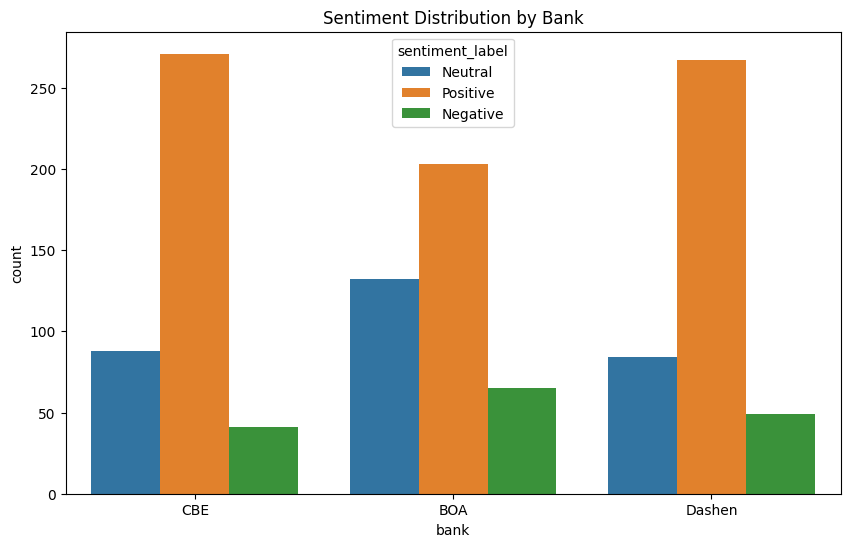

In [7]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="bank",
    hue="sentiment_label"
)

plt.title("Sentiment Distribution by Bank")

plt.show()

 avarage sentiment by bank and rating vs sentiment

In [8]:
df.groupby("bank")["sentiment_score"].mean()
df.groupby("rating")["sentiment_score"].mean()

rating
1   -0.134011
2    0.029845
3    0.095836
4    0.293202
5    0.392996
Name: sentiment_score, dtype: float64

text cleaning

In [9]:
stop_words = stopwords.words("english")

tf-idf analysis

In [10]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=20
)

X = tfidf.fit_transform(df["review"])

keywords = tfidf.get_feature_names_out()

keywords

array(['app', 'bank', 'banking', 'best', 'dashen', 'easy', 'fast', 'fix',
       'good', 'like', 'mobile', 'nice', 'service', 'super', 'time',
       'update', 'use', 'work', 'working', 'worst'], dtype=object)

keyword scores and visualization

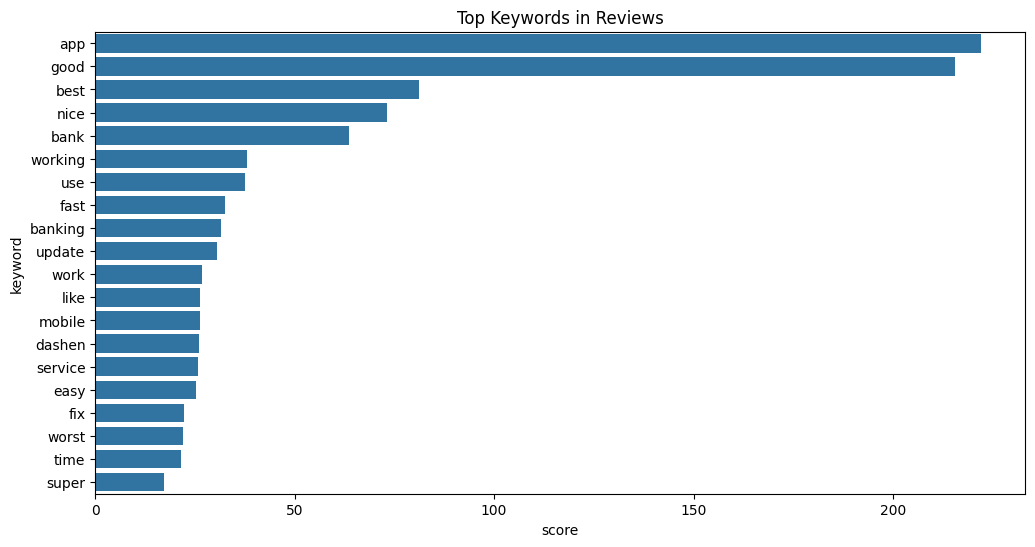

In [11]:
scores = X.sum(axis=0).A1

keyword_df = pd.DataFrame({
    "keyword": keywords,
    "score": scores
})

keyword_df = keyword_df.sort_values(
    by="score",
    ascending=False
)

keyword_df
plt.figure(figsize=(12, 6))

sns.barplot(
    data=keyword_df,
    x="score",
    y="keyword"
)

plt.title("Top Keywords in Reviews")

plt.show()

word cloud

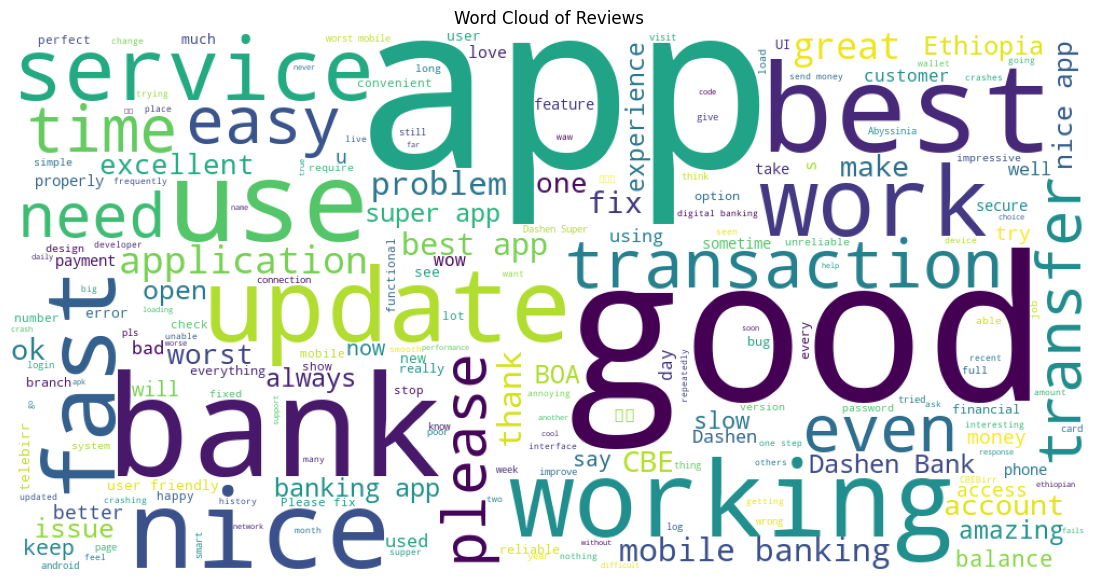

In [12]:
text = " ".join(df["review"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15, 7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Reviews")

plt.show()

Theme Identification

In [13]:
def identify_theme(review):

    review = str(review).lower()

    if "login" in review or "password" in review:
        return "Account Access Issues"

    elif "slow" in review or "transfer" in review:
        return "Transaction Performance"

    elif "ui" in review or "design" in review:
        return "UI & Design"

    elif "otp" in review:
        return "OTP Issues"

    else:
        return "General Feedback"

Apply Themes and Theme Counts

In [14]:
df["identified_theme"] = df["review"].apply(
    identify_theme
)

df.head()
df["identified_theme"].value_counts()

identified_theme
General Feedback           1108
Transaction Performance      51
UI & Design                  28
Account Access Issues        11
OTP Issues                    2
Name: count, dtype: int64

theme visualization

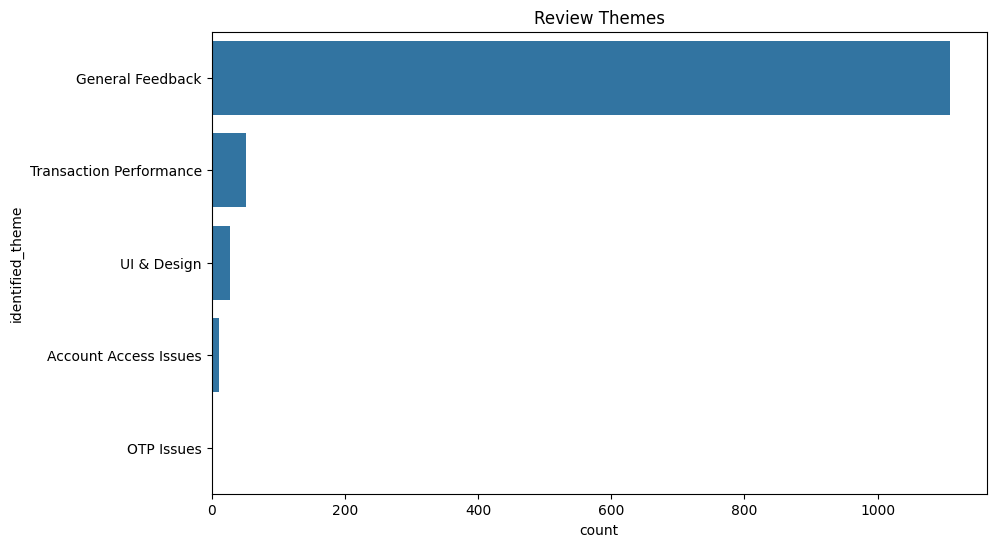

In [15]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="identified_theme",
    order=df["identified_theme"].value_counts().index
)

plt.title("Review Themes")

plt.show()

save processed data set

In [16]:
df.to_csv(
    "../data/sentiment_analysis_results.csv",
    index=False
)

print("Processed dataset saved.")

Processed dataset saved.
